# Setup and Imports

In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import os
import cv2 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm 
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from torch.optim import AdamW  
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import random
import time
# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration

In [3]:
# Set TEST_MODE = True for a quick end-to-end check.
# Set TEST_MODE = False for full training on the server.
TEST_MODE = False
TEST_SAMPLES = 200  


# Make cwd = notebook's folder so relative paths work regardless of launcher
try:
    os.chdir(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))   # VS Code
except NameError:
    pass
print('cwd:', os.getcwd())

# Directories
DATA_DIR       = './../data/raw'
MODEL_SAVE_DIR = './../models/model3_cnn_transformer_mtl'
RESULTS_DIR    = './../results/model3'

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Classes & Labels
CROSS_OUT_TYPES = ['SINGLE_LINE', 'DOUBLE_LINE', 'DIAGONAL', 'CROSS', 'WAVE', 'ZIG_ZAG', 'SCRATCH']
CROSS_OUT_LABELS = ['Single-Line', 'Double-Line', 'Diagonal', 'Cross', 'Wave', 'Zig-zag', 'Scratch']
NUM_CLASSES_TASK2 = len(CROSS_OUT_TYPES)

# Image Parameters
IMG_SIZE = 224
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD = [0.229, 0.224, 0.225]

# Hyperparameters
BATCH_SIZE = 16    if TEST_MODE else 64
NUM_EPOCHS = 2     if TEST_MODE else 50

# Differential Learning Rates (Model 3: 3 groups -- backbone / attention / heads)
LEARNING_RATE_BASE      = 5e-5   # pretrained EfficientNet backbone
LEARNING_RATE_ATTENTION = 3e-4   # fresh attention block (medium)
LEARNING_RATE_HEAD      = 1e-3   # fresh detection + classification heads
WEIGHT_DECAY = 1e-4

# Model 3 new: attention block config
ATTENTION_LAYERS = 2
ATTENTION_HEADS  = 8

# MTL Loss Weights
LAMBDA_DETECT = 1.0
LAMBDA_CLASS = 0.2

# Training Loop Configs
EARLY_STOPPING_PATIENCE = 5
SCHEDULER_PATIENCE = 3
SCHEDULER_FACTOR = 0.5
# Device-aware flags -- auto-configure for CUDA / MPS / CPU
NUM_WORKERS = 4 if torch.cuda.is_available() else 0
PIN_MEMORY  = torch.cuda.is_available()
USE_AMP     = torch.cuda.is_available()

# Hardware Setup
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

# Print Summary
if TEST_MODE:
    print('  TEST MODE ENABLED — quick end-to-end check')
    print(f'  Samples per split : {TEST_SAMPLES}')
    print('  Set TEST_MODE = False for full GPU training')
else:
    print('FULL TRAINING MODE ENABLED')
print(f'Device: {DEVICE} | Batch: {BATCH_SIZE} | Epochs: {NUM_EPOCHS}')
print(f'Save Directory: {os.path.abspath(MODEL_SAVE_DIR)}')

cwd: /project/crossout-detection/notebooks
FULL TRAINING MODE ENABLED
Device: cuda | Batch: 64 | Epochs: 50
Save Directory: /project/crossout-detection/models/model3_cnn_transformer_mtl


In [4]:
# Albumentations Pipeline
train_transforms = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Affine(
        translate_percent=(-0.05, 0.05), 
        scale=(1.0, 1.0),                
        rotate=(-10, 10),                
        border_mode=cv2.BORDER_CONSTANT, 
        fill=0,                          
        p=0.5
    ),
    A.ElasticTransform(alpha=1, sigma=50, p=0.5),
    A.OpticalDistortion(distort_limit=0.05, p=0.5), 
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.0, hue=0.0, p=0.5),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD),
    ToTensorV2()
])

In [5]:
# Dataset class
class MTLHandwritingDataset(Dataset):
    #Loads images and returns TWO labels per image for Multi-Task Learning
    def __init__(self, data_dir, split='train', transform=None):
        self.data_dir = os.path.join(data_dir, split, 'images')
        self.transform = transform
        
        self.images = []
        self.binary_labels = []     # For Detection Head
        self.multiclass_labels = [] # For Classification Head

        self._load_data()

    def _load_data(self):
        # Loading CLEAN images
        clean_dir = os.path.join(self.data_dir, 'CLEAN')
        if os.path.exists(clean_dir):
            for fname in os.listdir(clean_dir):
                if self._is_image(fname):
                    self.images.append(os.path.join(clean_dir, fname))
                    self.binary_labels.append(0)       # 0 = Clean
                    self.multiclass_labels.append(-100) # -100 = PyTorch Ignore Index

        # Loading CROSSED-OUT images 
        for idx, cross_type in enumerate(CROSS_OUT_TYPES):
            type_dir = os.path.join(self.data_dir, cross_type)
            if os.path.exists(type_dir):
                for fname in os.listdir(type_dir):
                    if self._is_image(fname):
                        self.images.append(os.path.join(type_dir, fname))
                        self.binary_labels.append(1)    # 1 = Crossed-out
                        self.multiclass_labels.append(idx) # 0 to 6 = Cross-out type

    def _is_image(self, fname):
        return fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.images[idx]).convert('RGB'))
        bin_label = self.binary_labels[idx]
        multi_label = self.multiclass_labels[idx]
        
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
            
        # Returning ONE image, but TWO labels
        return image, bin_label, multi_label

def get_mtl_dataloaders():
    train_ds = MTLHandwritingDataset(DATA_DIR, split='train', transform=train_transforms)
    val_ds   = MTLHandwritingDataset(DATA_DIR, split='val', transform=val_transforms)

    if TEST_MODE:
        rng = np.random.default_rng(SEED)
        train_ds = Subset(train_ds, rng.choice(len(train_ds), min(TEST_SAMPLES, len(train_ds)), replace=False).tolist())
        val_ds   = Subset(val_ds,   rng.choice(len(val_ds),   min(TEST_SAMPLES, len(val_ds)),   replace=False).tolist())

    if isinstance(train_ds, Subset):
        labels = np.array([train_ds.dataset.binary_labels[i] for i in train_ds.indices])
    else:
        labels = np.array(train_ds.binary_labels)
        
    class_counts = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[labels]
    
    train_sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_ds), replacement=True)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=False, 
        sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False, 
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )

    print(f"DataLoaders Ready. Train size: {len(train_ds)}, Val size: {len(val_ds)}")
    return train_loader, val_loader

In [6]:
def get_test_dataloaders(custom_data_path=None):
    iam_test_ds = MTLHandwritingDataset(DATA_DIR, split='test', transform=val_transforms)
    if TEST_MODE:
        rng = np.random.default_rng(SEED)
        iam_test_ds = Subset(iam_test_ds, rng.choice(len(iam_test_ds), min(TEST_SAMPLES, len(iam_test_ds)), replace=False).tolist())
        
    iam_test_loader = DataLoader(
        iam_test_ds, batch_size=BATCH_SIZE, shuffle=False, 
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    custom_test_loader = None
    if custom_data_path and os.path.exists(custom_data_path):
        custom_test_ds = MTLHandwritingDataset(custom_data_path, split='test', transform=val_transforms) 
        custom_test_loader = DataLoader(
            custom_test_ds, batch_size=BATCH_SIZE, shuffle=False, 
            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
        )
        print(f"Custom Test Dataset Loaded: {len(custom_test_ds)} images.")
        
    print(f"IAM Test Dataset Loaded: {len(iam_test_ds)} images.")
    return iam_test_loader, custom_test_loader

# Dataset Visualization

Generating Dataset Visualizations


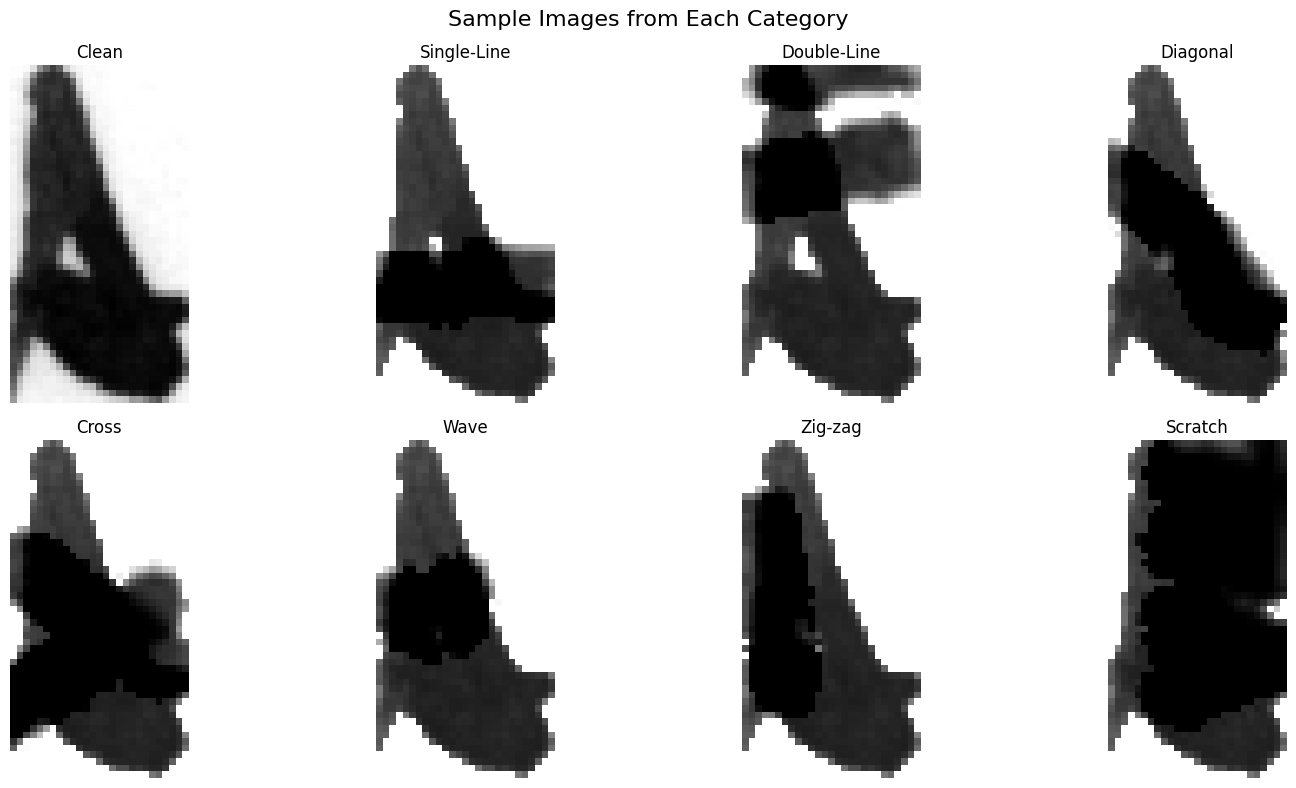

In [7]:
import numpy as np
from PIL import Image

print("Generating Dataset Visualizations")
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
folders = ['CLEAN'] + CROSS_OUT_TYPES
labels = ['Clean'] + CROSS_OUT_LABELS

for i, (folder, label) in enumerate(zip(folders[:8], labels[:8])):
    ax = axes[i // 4][i % 4]
    img_dir = os.path.join(DATA_DIR, 'train', 'images', folder)
    if os.path.exists(img_dir):
        img_name = sorted(os.listdir(img_dir))[0]
        img = Image.open(os.path.join(img_dir, img_name))
        ax.imshow(img, cmap='gray')
    ax.set_title(label, fontsize=12)
    ax.axis('off')

plt.suptitle('Sample Images from Each Category', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_images.png'), dpi=150)
plt.show()

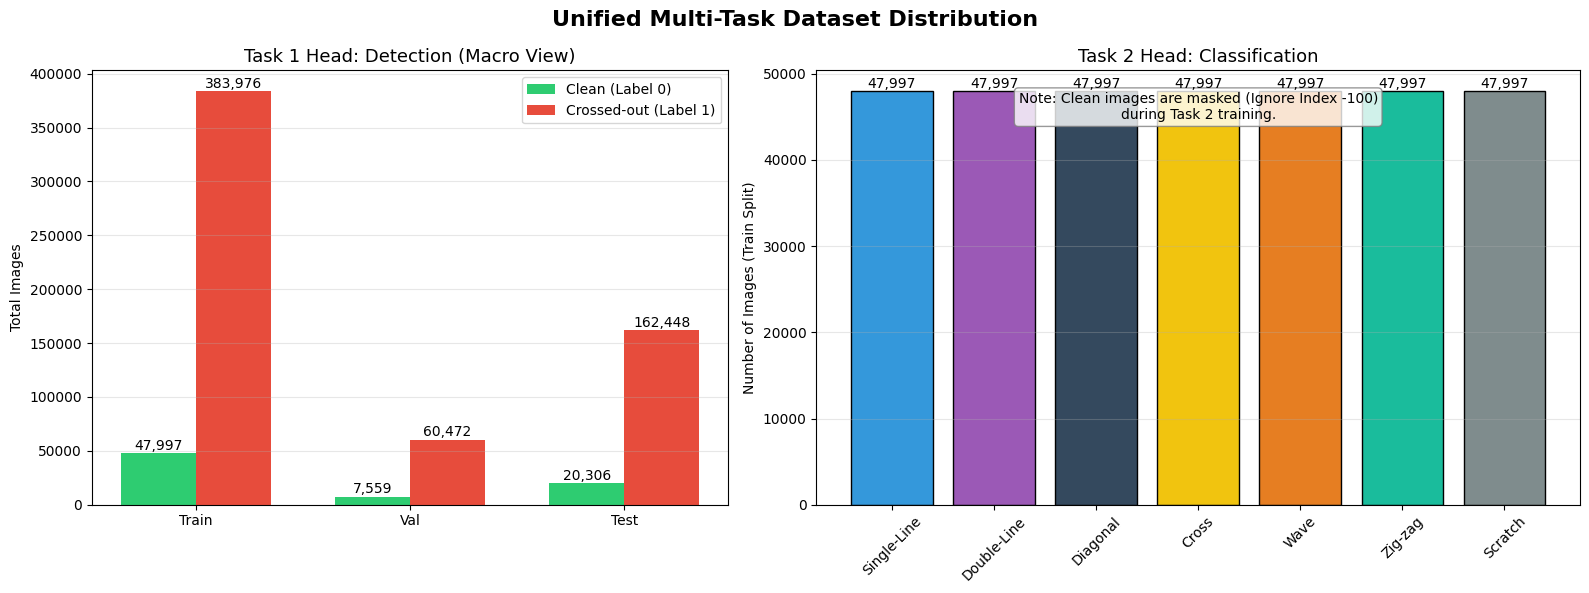

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Unified Multi-Task Dataset Distribution', fontsize=16, fontweight='bold')

binary_data = {'Clean': [], 'Crossed-out': []}
for split in ['train', 'val', 'test']:
    clean_dir = os.path.join(DATA_DIR, split, 'images', 'CLEAN')
    clean_count = len([f for f in os.listdir(clean_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]) if os.path.exists(clean_dir) else 0
    
    cross_count = 0
    for ct in CROSS_OUT_TYPES + ['MIXED']: 
        ct_dir = os.path.join(DATA_DIR, split, 'images', ct)
        if os.path.exists(ct_dir):
            cross_count += len([f for f in os.listdir(ct_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            
    binary_data['Clean'].append(clean_count)
    binary_data['Crossed-out'].append(cross_count)

type_counts = []
for ct in CROSS_OUT_TYPES:
    ct_dir = os.path.join(DATA_DIR, 'train', 'images', ct)
    count = len([f for f in os.listdir(ct_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]) if os.path.exists(ct_dir) else 0
    type_counts.append(count)

# The Detection Head's View (Macro)
x = np.arange(3)
width = 0.35
bars1 = axes[0].bar(x - width/2, binary_data['Clean'], width, label='Clean (Label 0)', color='#2ecc71')
bars2 = axes[0].bar(x + width/2, binary_data['Crossed-out'], width, label='Crossed-out (Label 1)', color='#e74c3c')

axes[0].set_xticks(x)
axes[0].set_xticklabels(['Train', 'Val', 'Test'])
axes[0].set_ylabel('Total Images')
axes[0].set_title('Task 1 Head: Detection (Macro View)', fontsize=13)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Adding value labels
for bar in bars1 + bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)

# The Classification Head's View (Micro)
colors = ['#3498db', '#9b59b6', '#34495e', '#f1c40f', '#e67e22', '#1abc9c', '#7f8c8d']
bars3 = axes[1].bar(CROSS_OUT_LABELS, type_counts, color=colors, edgecolor='black', linewidth=1)

axes[1].set_ylabel('Number of Images (Train Split)')
axes[1].set_title('Task 2 Head: Classification', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
axes[1].text(0.5, 0.95, "Note: Clean images are masked (Ignore Index -100)\nduring Task 2 training.", 
             transform=axes[1].transAxes, ha='center', va='top', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'mtl_dataset_distribution.png'), dpi=300)
plt.show()

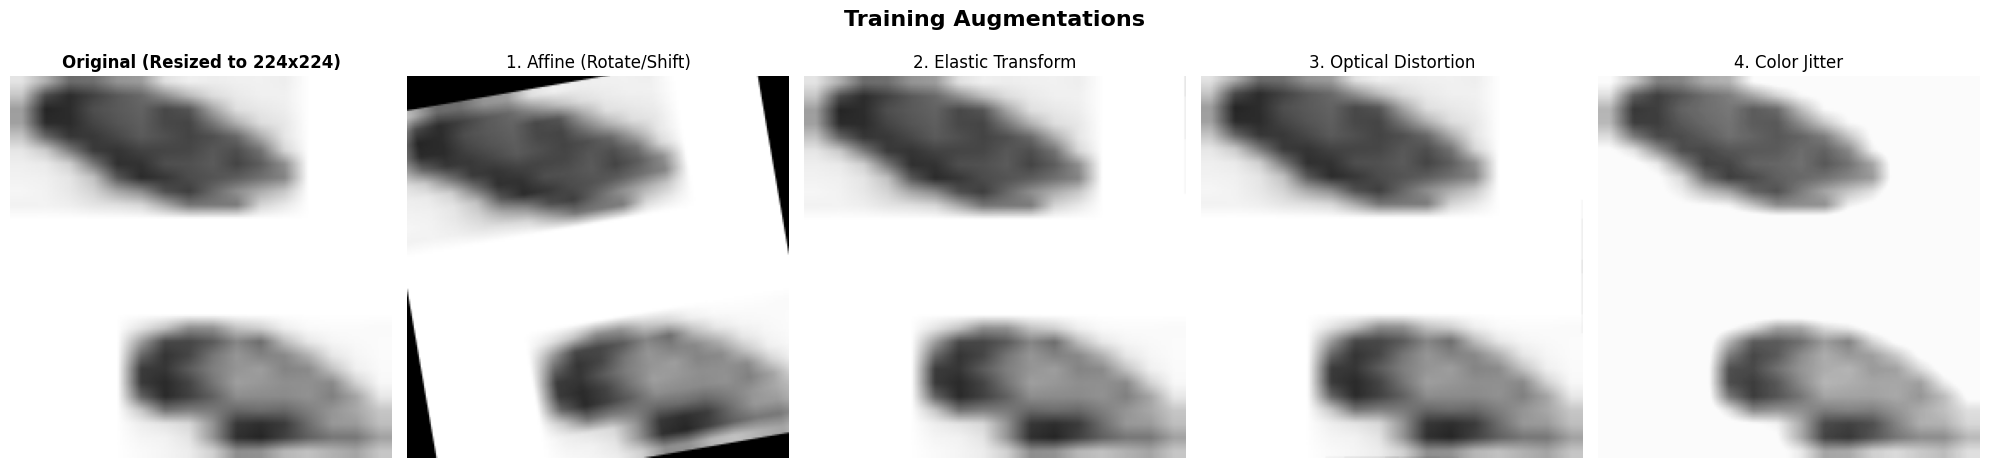

In [9]:
def visualize_specific_augmentations(image_path):
    # Loading the original image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    t_resize = A.Resize(height=IMG_SIZE, width=IMG_SIZE)
    base_image = t_resize(image=image)['image']

    t_affine = A.Affine(translate_percent=(-0.05, 0.05), scale=(1.0, 1.0), 
                        rotate=(-10, 10), border_mode=cv2.BORDER_CONSTANT, fill=0, p=1.0)
    t_elastic = A.ElasticTransform(alpha=1, sigma=50, p=1.0)
    t_optical = A.OpticalDistortion(distort_limit=0.05, p=1.0)
    t_color = A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.0, hue=0.0, p=1.0)
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))

    axes[0].imshow(base_image)
    axes[0].set_title(f"Original (Resized to {IMG_SIZE}x{IMG_SIZE})", fontweight='bold')
    
    axes[1].imshow(t_affine(image=base_image)['image'])
    axes[1].set_title("1. Affine (Rotate/Shift)")
    
    axes[2].imshow(t_elastic(image=base_image)['image'])
    axes[2].set_title("2. Elastic Transform")
    
    axes[3].imshow(t_optical(image=base_image)['image'])
    axes[3].set_title("3. Optical Distortion")
    
    axes[4].imshow(t_color(image=base_image)['image'])
    axes[4].set_title("4. Color Jitter")
    
    for ax in axes:
        ax.axis('off')
        
    plt.suptitle("Training Augmentations", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'augmentation.png'), dpi=300)
    plt.show()

# Run the plot
sample_crossout = os.path.join(DATA_DIR, 'train', 'images', CROSS_OUT_TYPES[0])
if os.path.exists(sample_crossout):
    sample_img_file = os.path.join(sample_crossout, os.listdir(sample_crossout)[5])
    visualize_specific_augmentations(sample_img_file)
else:
    print(f"Error: Could not find the directory at {sample_crossout}")

# Model Architecture

## Model 3: Attention Block (added on top of Model 2)

**WHY we add this:**  
Model 2 uses EfficientNet features but then does Global Average Pooling, which throws away WHERE things are. That hurts classes like Diagonal vs Zig-zag where the stroke **TRAJECTORY** matters, not just the texture.

**WHAT this block does:**  
Treats the 7×7 feature map as a sequence of 49 "tokens" and lets every token look at every other token using self-attention. This preserves spatial information.

**STRUCTURE** (standard transformer block):
```
LayerNorm -> Multi-Head Attention -> + residual
LayerNorm -> Small MLP            -> + residual
```

In [10]:
class AttentionBlock(nn.Module):
    def __init__(self, feature_dim=1280, num_heads=8, dropout=0.1):
        super().__init__()

        # Learnable "where am I?" embedding for each of the 49 positions.
        # Initialised to small random values so it doesn't overpower features.
        self.position_embedding = nn.Parameter(torch.zeros(1, 49, feature_dim))
        nn.init.trunc_normal_(self.position_embedding, std=0.02)

        # Pre-norm layers (norm BEFORE attention/MLP: more stable training)
        self.norm_before_attention = nn.LayerNorm(feature_dim)
        self.norm_before_mlp       = nn.LayerNorm(feature_dim)

        # Multi-Head Self-Attention: each of 8 heads looks at different patterns
        self.attention = nn.MultiheadAttention(
            embed_dim=feature_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,   # input shape is (batch, tokens, features)
        )

        # Small 2-layer MLP after attention (standard in transformers)
        mlp_hidden = feature_dim * 2
        self.mlp = nn.Sequential(
            nn.Linear(feature_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, feature_dim),
            nn.Dropout(dropout),
        )

    def forward(self, tokens, add_position=True):
        # tokens shape: (batch, 49, 1280)

        # Step 1: add position info (only on the first block)
        if add_position:
            tokens = tokens + self.position_embedding

        # Step 2: self-attention with residual connection
        normed = self.norm_before_attention(tokens)
        attention_output, _ = self.attention(normed, normed, normed)
        tokens = tokens + attention_output   # residual

        # Step 3: MLP with residual connection
        tokens = tokens + self.mlp(self.norm_before_mlp(tokens))

        return tokens

# Model 3 Network: Model 2's backbone + heads, with attention inserted
class EfficientNetMTL(nn.Module):
    """
    Model 3 = Model 2 + attention blocks on the 7x7 feature map.
    The two MTL heads (detection + classification) are unchanged from Model 2,
    and forward() still returns a tuple (out_detect, out_class).
    """
    def __init__(self, num_classes_task2=NUM_CLASSES_TASK2,
                 attention_layers=ATTENTION_LAYERS,
                 attention_heads=ATTENTION_HEADS):
        super().__init__()

        # Backbone (same as Model 2)
        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        feature_dim = self.backbone.classifier[1].in_features   # 1280

        # We'll use self.backbone.features(x) directly to get the 7x7 map,
        # so we remove the default pool and classifier.
        self.backbone.avgpool    = nn.Identity()
        self.backbone.classifier = nn.Identity()

        # NEW: stack of attention blocks
        self.attention_blocks = nn.ModuleList([
            AttentionBlock(feature_dim=feature_dim, num_heads=attention_heads)
            for _ in range(attention_layers)
        ])

        # MTL Heads (same as Model 2)
        self.detection_head = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(feature_dim, 1)         # 1 logit: clean vs crossed-out
        )
        self.classification_head = nn.Sequential(
            nn.Dropout(p=0.2),
            nn.Linear(feature_dim, num_classes_task2)   # 7 logits: cross-out type
        )

    def forward(self, x):
        # 1. CNN extracts a spatial feature map
        #    Input: (batch, 3, 224, 224)  ->  Output: (batch, 1280, 7, 7)
        feature_map = self.backbone.features(x)

        # 2. Flatten the 7x7 grid into a sequence of 49 tokens
        #    (batch, 1280, 7, 7) -> (batch, 49, 1280)
        batch, channels, height, width = feature_map.shape
        tokens = feature_map.flatten(2).transpose(1, 2)

        # 3. Run through attention blocks (position added only on first block)
        for i, block in enumerate(self.attention_blocks):
            tokens = block(tokens, add_position=(i == 0))

        # 4. Pool the 49 tokens into one vector per image
        #    (batch, 49, 1280) -> (batch, 1280)
        shared_features = tokens.mean(dim=1)

        # 5. Two heads share the same features
        out_detect = self.detection_head(shared_features)
        out_class  = self.classification_head(shared_features)
        return out_detect, out_class


# Build the model and load Model 2's backbone weights (warm-start)
print("Initializing Model 3 (CNN + Transformer + MTL)")
model = EfficientNetMTL(num_classes_task2=NUM_CLASSES_TASK2)

# Try Model 2 backbone first, fall back to Model 1 if not available
model2_backbone_path = '../models/model2_efficientnet_mtl/backbone_model2.pth'
model1_backbone_path = '../models/model1_efficientnet/backbone_task2_2.pth'

if os.path.exists(model2_backbone_path):
    backbone_path = model2_backbone_path
elif os.path.exists(model1_backbone_path):
    backbone_path = model1_backbone_path
    print("Note: Model 2 backbone not found, falling back to Model 1 backbone.")
else:
    backbone_path = None
    print("WARNING: No pretrained backbone found. Training from ImageNet weights only.")

if backbone_path:
    checkpoint = torch.load(backbone_path, map_location=DEVICE)
    model.backbone.features.load_state_dict(checkpoint['state_dict'], strict=False)
    print(f"Loaded backbone weights from: {backbone_path}")

model = model.to(DEVICE)

# Print how many parameters we have (handy to report in the presentation)
total_params     = sum(p.numel() for p in model.parameters())
attention_params = sum(p.numel() for p in model.attention_blocks.parameters())
print(f"Total parameters:     {total_params:,}")
print(f"Attention parameters: {attention_params:,}")

Initializing Model 3 (CNN + Transformer + MTL)
Loaded backbone weights from: ../models/model2_efficientnet_mtl/backbone_model2.pth
Total parameters:     30,385,796
Attention parameters: 26,368,000


# Training Loops

In [11]:
def train_one_epoch_mtl(model, dataloader, criterion_detect, criterion_class, optimizer, scaler):
    model.train()
    running_loss = 0.0
    
    for images, labels_detect, labels_class in tqdm(dataloader, desc='Training MTL', leave=False):
        images = images.to(DEVICE)
        labels_detect = labels_detect.to(DEVICE).float()
        labels_class = labels_class.to(DEVICE).long()
        
        optimizer.zero_grad()
        
        # forward pass
        with torch.autocast(device_type=DEVICE if USE_AMP else 'cpu', dtype=torch.float16, enabled=USE_AMP):
            out_detect, out_class = model(images)
            out_detect = out_detect.squeeze(1)

            loss_detect = criterion_detect(out_detect, labels_detect)
            if (labels_class != -100).sum() > 0:
                loss_class = criterion_class(out_class, labels_class)
            else:
                loss_class = torch.tensor(0.0, device=DEVICE)

            total_loss = (LAMBDA_DETECT * loss_detect) + (LAMBDA_CLASS * loss_class)
            
        # Backward pass
        scaler.scale(total_loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += total_loss.item() * images.size(0)
        
    return running_loss / len(dataloader.dataset)

# Validation Loop
def validate_mtl(model, dataloader, criterion_detect, criterion_class):
    model.eval()
    running_loss = 0.0
    correct_detect, total_detect = 0, 0
    correct_class, total_class = 0, 0
    
    with torch.no_grad():
        for images, labels_detect, labels_class in tqdm(dataloader, desc='Validating MTL', leave=False):
            images = images.to(DEVICE)
            labels_detect = labels_detect.to(DEVICE).float()
            labels_class = labels_class.to(DEVICE).long()
            
            out_detect, out_class = model(images)
            out_detect = out_detect.squeeze(1)

            loss_detect = criterion_detect(out_detect, labels_detect)

            if (labels_class != -100).sum() > 0:
                loss_class = criterion_class(out_class, labels_class)
            else:
                loss_class = torch.tensor(0.0, device=DEVICE)

            total_loss = (LAMBDA_DETECT * loss_detect) + (LAMBDA_CLASS * loss_class)
            running_loss += total_loss.item() * images.size(0)
            
            # Calculating Detection Accuracy
            preds_detect = (out_detect > 0.0).float() 
            correct_detect += (preds_detect == labels_detect).sum().item()
            total_detect += labels_detect.size(0)
            
            # Calculating Classification Accuracy
            valid_class_mask = labels_class != -100
            if valid_class_mask.sum() > 0:
                preds_class = torch.argmax(out_class, dim=1)
                correct_class += (preds_class[valid_class_mask] == labels_class[valid_class_mask]).sum().item()
                total_class += valid_class_mask.sum().item()
            
    epoch_loss = running_loss / len(dataloader.dataset)
    val_det_acc = correct_detect / total_detect if total_detect > 0 else 0.0
    val_cls_acc = correct_class / total_class if total_class > 0 else 0.0
    
    return epoch_loss, val_det_acc, val_cls_acc

def train_mtl_model(model, train_loader, val_loader, save_path):
    history = {
        'train_loss': [], 
        'val_loss': [], 
        'val_det_acc': [], 
        'val_cls_acc': []
    }
    
    # Model 3: 3 parameter groups -- backbone / attention / heads
    optimizer = AdamW([
        {'params': model.backbone.parameters(),            'lr': LEARNING_RATE_BASE}, 
        {'params': model.attention_blocks.parameters(),    'lr': LEARNING_RATE_ATTENTION},
        {'params': model.detection_head.parameters(),      'lr': LEARNING_RATE_HEAD},
        {'params': model.classification_head.parameters(), 'lr': LEARNING_RATE_HEAD}
    ], weight_decay=WEIGHT_DECAY)
    
    criterion_detect = nn.BCEWithLogitsLoss()
    criterion_class = nn.CrossEntropyLoss(ignore_index=-100)
    
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=SCHEDULER_PATIENCE, factor=SCHEDULER_FACTOR)
    scaler = torch.amp.GradScaler(enabled=USE_AMP)
    
    best_val_loss = float('inf')
    epochs_without_improvement = 0 
    
    print(f"Starting MTL Training on {DEVICE}")
    total_start_time = time.time()
    for epoch in range(NUM_EPOCHS): 
        epoch_start_time = time.time()
        train_loss = train_one_epoch_mtl(model, train_loader, criterion_detect, criterion_class, optimizer, scaler)
        val_loss, val_det_acc, val_cls_acc = validate_mtl(model, val_loader, criterion_detect, criterion_class)
        
        scheduler.step(val_loss)
        epoch_end_time = time.time()
        epoch_mins, epoch_secs = divmod(epoch_end_time - epoch_start_time, 60)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
              f"Time: {int(epoch_mins)}m {int(epoch_secs)}s | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Detect Acc: {val_det_acc:.4f} | "
              f"Val Class Acc: {val_cls_acc:.4f} | "
              f"LR: {current_lr:.6f}")
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_det_acc'].append(val_det_acc)
        history['val_cls_acc'].append(val_cls_acc)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
            }, save_path)
            print(f"  -> Checkpoint Saved to {save_path}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

    total_time = time.time() - total_start_time
    total_mins, total_secs = divmod(total_time, 60)
    print(f"\n Training Completed in {int(total_mins)}m {int(total_secs)}s")
    return model, history

In [12]:
#  EXECUTION
train_loader, val_loader = get_mtl_dataloaders()
final_save_path = os.path.join(MODEL_SAVE_DIR, 'best_model3.pth')
trained_model, history = train_mtl_model(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    save_path=final_save_path
)

DataLoaders Ready. Train size: 383976, Val size: 60472
Starting MTL Training on cuda


Epoch [1/50] Time: 16m 56s | Train Loss: 0.1356 | Val Loss: 0.1403 | Val Detect Acc: 0.9047 | Val Class Acc: 0.8995 | LR: 0.000050
  -> Checkpoint Saved to ./../models/model3_cnn_transformer_mtl/best_model3.pth


Epoch [2/50] Time: 16m 58s | Train Loss: 0.1208 | Val Loss: 0.1464 | Val Detect Acc: 0.9078 | Val Class Acc: 0.8986 | LR: 0.000050


Epoch [3/50] Time: 16m 45s | Train Loss: 0.1169 | Val Loss: 0.1561 | Val Detect Acc: 0.9050 | Val Class Acc: 0.8999 | LR: 0.000050


Epoch [4/50] Time: 16m 56s | Train Loss: 0.1158 | Val Loss: 0.1406 | Val Detect Acc: 0.9045 | Val Class Acc: 0.8997 | LR: 0.000050


...

Epoch [15/50] Time: 16m 46s | Train Loss: 0.1068 | Val Loss: 0.1388 | Val Detect Acc: 0.9045 | Val Class Acc: 0.9014 | LR: 0.000025


Epoch [16/50] Time: 17m 18s | Train Loss: 0.1066 | Val Loss: 0.1421 | Val Detect Acc: 0.9045 | Val Class Acc: 0.9018 | LR: 0.000025


Epoch [17/50] Time: 17m 51s | Train Loss: 0.1082 | Val Loss: 0.1310 | Val Detect Acc: 0.9048 | Val Class Acc: 0.9017 | LR: 0.000025


Epoch [18/50] Time: 17m 56s | Train Loss: 0.1064 | Val Loss: 0.1332 | Val Detect Acc: 0.9062 | Val Class Acc: 0.9018 | LR: 0.000013


Epoch [19/50] Time: 17m 59s | Train Loss: 0.1070 | Val Loss: 0.1306 | Val Detect Acc: 0.9085 | Val Class Acc: 0.9018 | LR: 0.000013
Early stopping triggered after 19 epochs.

 Training Completed in 320m 59s


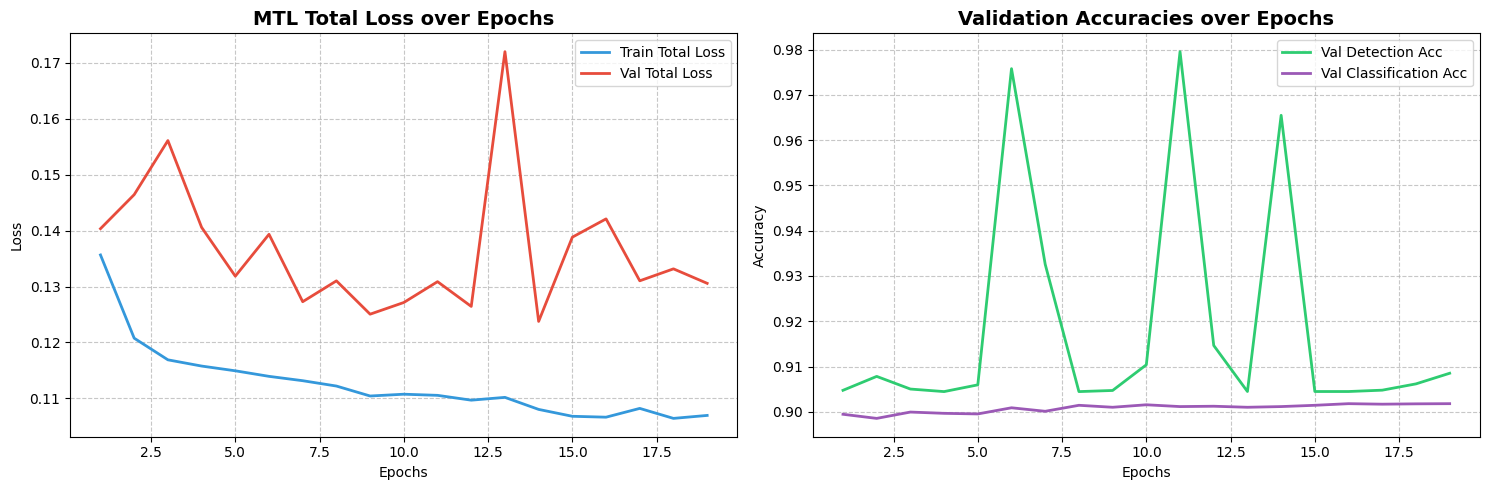

In [13]:
def plot_mtl_training_curves(history, save_dir=RESULTS_DIR):
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Total Loss
    axes[0].plot(epochs, history['train_loss'], label='Train Total Loss', color='#3498db', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], label='Val Total Loss', color='#e74c3c', linewidth=2)
    axes[0].set_title('MTL Total Loss over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Plot 2: Task Accuracies (Validation)
    axes[1].plot(epochs, history['val_det_acc'], label='Val Detection Acc', color='#2ecc71', linewidth=2)
    axes[1].plot(epochs, history['val_cls_acc'], label='Val Classification Acc', color='#9b59b6', linewidth=2)
    axes[1].set_title('Validation Accuracies over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'mtl_training_curves.png'), dpi=300)
    plt.show()

plot_mtl_training_curves(history)

In [14]:
def evaluate_mtl(model, dataloader):
    """Runs data through the frozen model and collects predictions."""
    model.eval()
    
    # Storage arrays
    all_detect_trues, all_detect_preds = [], []
    all_class_trues, all_class_preds = [], []
    
    with torch.no_grad():
        for images, labels_detect, labels_class in tqdm(dataloader, desc='Evaluating MTL', leave=False):
            images = images.to(DEVICE)
            
            # Forward pass
            out_detect, out_class = model(images)
            
            # Task 1: Binary Detection Logic
            probs_detect = torch.sigmoid(out_detect.squeeze(1))
            preds_detect = (probs_detect > 0.5).long().cpu().numpy()
            trues_detect = labels_detect.long().cpu().numpy()
            
            all_detect_trues.extend(trues_detect)
            all_detect_preds.extend(preds_detect)
            
            # Task 2: Multiclass Classification Logic
            preds_class = torch.argmax(out_class, dim=1).cpu().numpy()
            trues_class = labels_class.cpu().numpy()
            valid_mask = trues_class != -100
            
            all_class_trues.extend(trues_class[valid_mask])
            all_class_preds.extend(preds_class[valid_mask])
            
    return all_detect_trues, all_detect_preds, all_class_trues, all_class_preds


# Testing and Visualization

Loading Best Model for Final Evaluation
IAM Test Dataset Loaded: 162448 images.

EVALUATING ON PUBLIC DATA (IAM TEST SET)



--- TASK 1: DETECTION (Clean vs Cross-out) ---
              precision    recall  f1-score   support

       Clean     0.8162    0.9286    0.8688     20306
 Crossed-out     0.9896    0.9701    0.9798    142142

    accuracy                         0.9649    162448
   macro avg     0.9029    0.9494    0.9243    162448
weighted avg     0.9679    0.9649    0.9659    162448



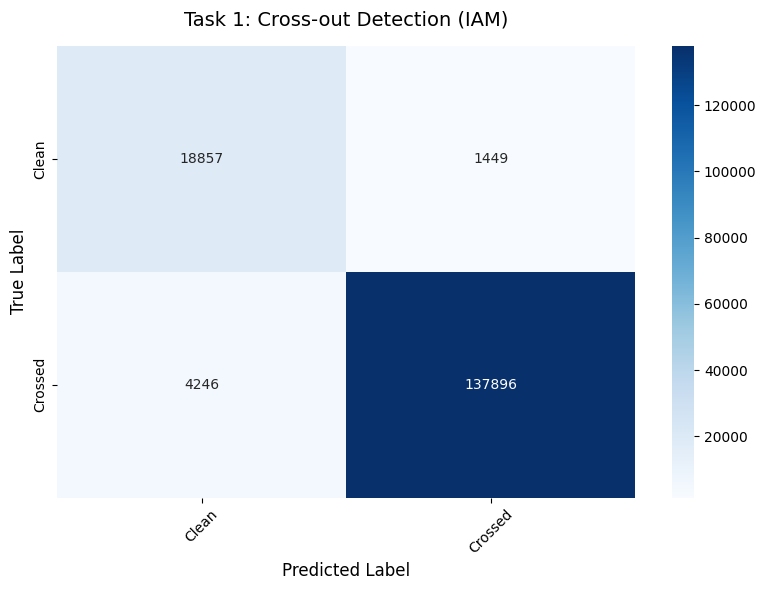


--- TASK 2: CLASSIFICATION (Cross-out Type) ---
              precision    recall  f1-score   support

 Single-Line     0.9939    0.8973    0.9432     20306
 Double-Line     0.9990    0.8956    0.9445     20306
    Diagonal     0.9656    0.9025    0.9330     20306
       Cross     0.6368    0.9924    0.7758     20306
        Wave     0.9918    0.8838    0.9347     20306
     Zig-zag     0.9742    0.8930    0.9319     20306
     Scratch     0.9989    0.8988    0.9462     20306

    accuracy                         0.9091    142142
   macro avg     0.9372    0.9091    0.9156    142142
weighted avg     0.9372    0.9091    0.9156    142142



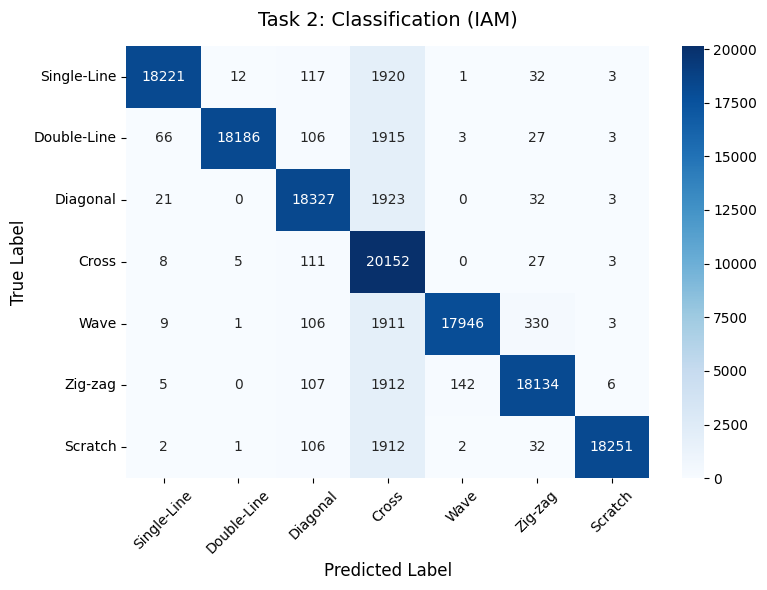


EVALUATING ON CUSTOM 50-IMAGE SET
No custom test loader provided. Skipping custom evaluation.


In [15]:
def plot_confusion_matrix(trues, preds, classes, title, save_name=None):
    """Draws a professional Seaborn heatmap for the report."""
    cm = confusion_matrix(trues, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(title, fontsize=14, pad=15)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    if save_name:
        plt.savefig(os.path.join(RESULTS_DIR, save_name), dpi=300)
    plt.show()

# EXECUTION SCRIPT
print("Loading Best Model for Final Evaluation")
checkpoint = torch.load(final_save_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

CUSTOM_DATA_PATH = None 
iam_test_loader, custom_test_loader = get_test_dataloaders(custom_data_path=CUSTOM_DATA_PATH)

# --- Evaluating IAM Test set ---
print("\n" + "="*50)
print("EVALUATING ON PUBLIC DATA (IAM TEST SET)")
print("="*50)

if iam_test_loader:
    det_t, det_p, cls_t, cls_p = evaluate_mtl(model, iam_test_loader)
    
    print("\n--- TASK 1: DETECTION (Clean vs Cross-out) ---")
    print(classification_report(det_t, det_p, target_names=['Clean', 'Crossed-out'], digits=4))
    plot_confusion_matrix(det_t, det_p, ['Clean', 'Crossed'], 
                          "Task 1: Cross-out Detection (IAM)", "task1_cm_iam.png")
    
    print("\n--- TASK 2: CLASSIFICATION (Cross-out Type) ---")
    print(classification_report(cls_t, cls_p, target_names=CROSS_OUT_LABELS, digits=4))
    plot_confusion_matrix(cls_t, cls_p, CROSS_OUT_LABELS, 
                          "Task 2: Classification (IAM)", "task2_cm_iam.png")

# Evaluating Custom Dataset
print("\n" + "="*50)
print("EVALUATING ON CUSTOM 50-IMAGE SET")
print("="*50)

if custom_test_loader:
    c_det_t, c_det_p, c_cls_t, c_cls_p = evaluate_mtl(model, custom_test_loader)
    
    print("\nTASK 1: DETECTION (Custom Data)")
    print(classification_report(c_det_t, c_det_p, target_names=['Clean', 'Crossed-out'], digits=4))
    plot_confusion_matrix(c_det_t, c_det_p, ['Clean', 'Crossed'], 
                          "Task 1: Cross-out Detection (Custom)", "task1_cm_custom.png")
    
    print("\nTASK 2: CLASSIFICATION (Custom Data)")
    print(classification_report(c_cls_t, c_cls_p, target_names=CROSS_OUT_LABELS, digits=4))
    plot_confusion_matrix(c_cls_t, c_cls_p, CROSS_OUT_LABELS, 
                          "Task 2: Classification (Custom)", "task2_cm_custom.png")
else:
    print("No custom test loader provided. Skipping custom evaluation.")

In [16]:
# Save Backbone
print("EXTRACTING MODEL 3 BACKBONE")

mtl_backbone_save_path = os.path.join(MODEL_SAVE_DIR, 'backbone_model3.pth')
backbone_state_dict = model.backbone.features.state_dict()
torch.save({'state_dict': backbone_state_dict}, mtl_backbone_save_path)

print(f" Model 3 Backbone successfully extracted and saved to:")
print(f" -> {os.path.abspath(mtl_backbone_save_path)}")

EXTRACTING MODEL 3 BACKBONE
 Model 3 Backbone successfully extracted and saved to:
 -> /project/crossout-detection/models/model3_cnn_transformer_mtl/backbone_model3.pth
